<a href="https://colab.research.google.com/github/ruki-2003/Database-And-Analytics-34150798/blob/main/Assignment_Section1_and_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility & Logistics
# Section 1: SQL in R
# Tool: sqldf (SQL queries on R data frames)

In [ ]:
install.packages("sqldf")
install.packages("ggplot2")
library(sqldf)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [ ]:
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE)
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE)

# Quick sanity check
cat("Rows loaded:\n")
cat("  customers:",  nrow(customers),  "\n")
cat("  orders:",     nrow(orders),     "\n")
cat("  deliveries:", nrow(deliveries), "\n")
cat("  drivers:",    nrow(drivers),    "\n")
cat("  hubs:",       nrow(hubs),       "\n")

Rows loaded:
  customers: 650 
  orders: 1250 
  deliveries: 950 
  drivers: 170 
  hubs: 8 


In [ ]:
library(dplyr)

clean_zone <- function(zone) {
  zone <- trimws(zone)           # remove extra spaces
  zone <- tolower(zone)          # make all lowercase first

  zone <- case_when(
    zone %in% c("ctr", "central")          ~ "Central",
    zone %in% c("north")                   ~ "North",
    zone %in% c("south")                   ~ "South",
    zone %in% c("east")                    ~ "East",
    zone %in% c("west")                    ~ "West",
    zone %in% c("airport")                 ~ "Airport",
    zone %in% c("riverside", "riverSide")  ~ "Riverside",
    TRUE ~ tools::toTitleCase(zone)        # catch anything else
  )
  return(zone)
}

# Apply cleaning to all relevant tables
orders$pickup_zone    <- clean_zone(orders$pickup_zone)
orders$dropoff_zone   <- clean_zone(orders$dropoff_zone)
drivers$base_zone     <- clean_zone(drivers$base_zone)
hubs$zone             <- clean_zone(hubs$zone)

cat("Zone names after cleaning:\n")
cat("Orders pickup zones:", paste(unique(orders$pickup_zone), collapse = ", "), "\n")
cat("Hub zones:", paste(unique(hubs$zone), collapse = ", "), "\n")

Zone names after cleaning:
Orders pickup zones: Airport, North, West, Riverside, Central, South, East 
Hub zones: North, South, East, West, Central, Airport, Riverside 


# QUERY 1: Delivery Status Summary
# Business question: What proportion of deliveries are failing or being delayed across the NorthStar network?

In [ ]:
q1 <- sqldf("
  SELECT
    delivery_status,
    COUNT(*)                          AS total_deliveries,
    ROUND(COUNT(*) * 100.0
          / (SELECT COUNT(*) FROM deliveries), 2) AS percentage
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

cat("\n--- Q1: Overall Delivery Status Breakdown ---\n")
print(q1)


--- Q1: Overall Delivery Status Breakdown ---
  delivery_status total_deliveries percentage
1          OnTime              616      64.84
2         Delayed              202      21.26
3          Failed              132      13.89


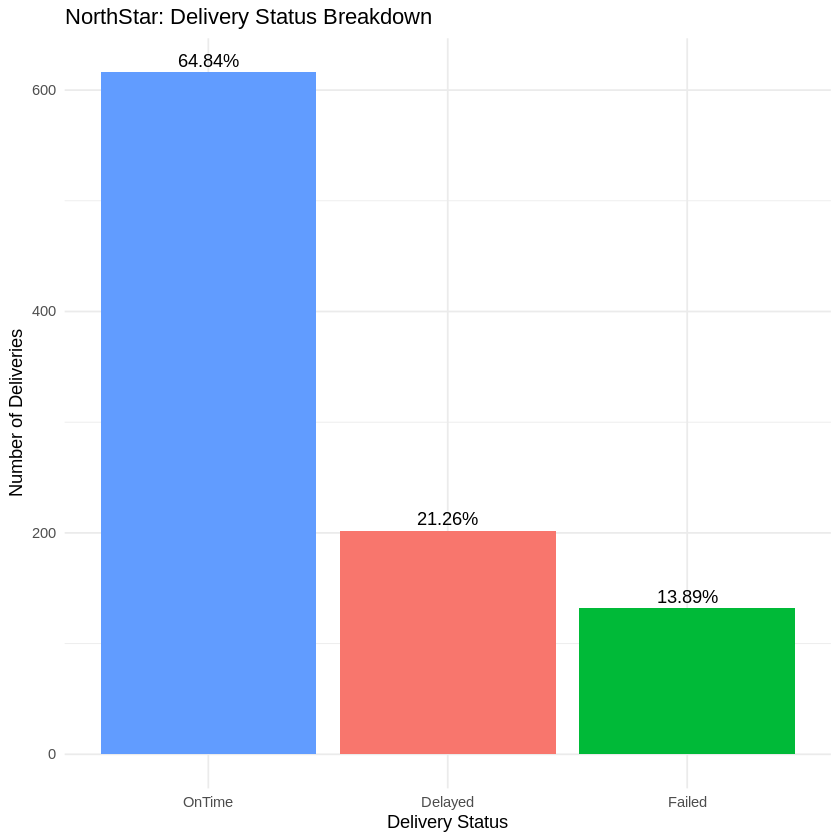

In [ ]:
# Visualise Q1
ggplot(q1, aes(x = reorder(delivery_status, -total_deliveries),
               y = total_deliveries,
               fill = delivery_status)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(percentage, "%")), vjust = -0.4) +
  labs(title = "NorthStar: Delivery Status Breakdown",
       x = "Delivery Status", y = "Number of Deliveries") +
  theme_minimal() +
  theme(legend.position = "none")

This chart provides the foundational picture of NorthStar's delivery performance across the entire network. While 64.84% of deliveries are completed on time, the remaining 35.15% represent a serious operational failure that directly supports the concerns raised by senior management in the case study.
Delayed deliveries account for 21.26% of all orders — over 1 in 5 deliveries arriving late. This is particularly significant because delays often precede outright failures; customers who experience repeated delays are likely to generate the rising complaint volumes NorthStar has been observing.
More critically, 13.89% of deliveries fail entirely — meaning 132 out of 950 deliveries never reach their destination successfully. For a logistics company whose core value proposition is reliable urban delivery, a failure rate of nearly 1 in 7 deliveries is commercially damaging and reputationally unsustainable.
Combined, more than 1 in 3 deliveries (35.15%) does not meet its service commitment, which aligns directly with the case study's description of increasing customer complaints, missed delivery windows, and growing pressure from the board to explain why operational performance is deteriorating despite rising demand.
This baseline finding sets the context for all subsequent analyses — the zone, hub, driver, and priority-level breakdowns explored in Q2–Q6 all seek to explain where and why this 35% non-performance rate is occurring across NorthStar's network.

# QUERY 2: Delivery Failure Rate by Pickup Zone
# Business question: Which city zones consistently have the highest rate of failed or delayed deliveries?

In [ ]:
q2 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id)                         AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                  AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed'
             THEN 1 ELSE 0 END)                  AS delayed,
    ROUND(
      (SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed')
                THEN 1 ELSE 0 END) * 100.0)
      / COUNT(d.delivery_id), 2)                 AS failure_rate_pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

cat("\n--- Q2: Delivery Failure Rate by Pickup Zone ---\n")
print(q2)


--- Q2: Delivery Failure Rate by Pickup Zone ---
  pickup_zone total_deliveries failed delayed failure_rate_pct
1     Central              174     33      51            48.28
2     Airport              113     12      31            38.05
3   Riverside              119     18      25            36.13
4        East              156     19      31            32.05
5       North              135     22      21            31.85
6        West              114     14      21            30.70
7       South              139     14      22            25.90


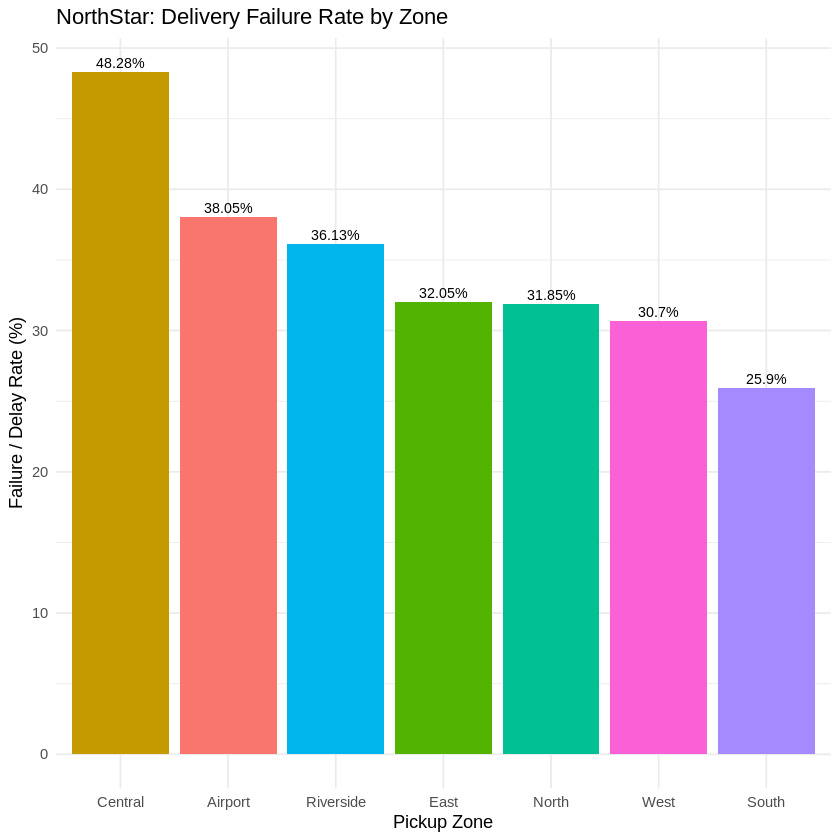

In [ ]:
# Visualise Q2
ggplot(q2, aes(x = reorder(pickup_zone, -failure_rate_pct),
               y = failure_rate_pct, fill = pickup_zone)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(failure_rate_pct, "%")), vjust = -0.4, size = 3) +
  labs(title = "NorthStar: Delivery Failure Rate by Zone",
       x = "Pickup Zone", y = "Failure / Delay Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")


this analysis reveals Central as N stars most problematic zone with a combined failure and delay rate of 48.28%. which depicts nearly half of all deliveries originating from Central either fail or are delayed. With 174 total deliveries it is also one of the busiest zones thus the operational impact is significant.

airport and Riverside that perform at 38 05 percent and 36.13% respectively followers The second and third worst performing zones. The airport zone's high failure rate is particularly concerning given that the airport is linked to services that have strict time windows and making delays can especially damage customer satisfaction and service contracts.

The East, North and West Zones containing the failure and delay rate of 32.05% 31.85% and 30.70% respectively form a middle cluster with broadly similar failure rates suggesting shared systematic issues rather than isolated zone specific problems. This could be potentially linked to route planning of fleet allocation across these areas.

South performs best at 25.90%, yet this figure depicts roughly 1 in 4 deliveries are failed or being delayed, which id still a high baseline that Northstar needs to address network-wide.

In conclusion, Central requires urgent intervention, while overall network failure rates remain unacceptably high across all zones, reinforcing the case study's description of a business where operational efficiency has become more systemic rather than localised.

# QUERY 3: Hub Performance — Failure Rate & Avg Customer Rating
# Business question: Which operational hubs are contributing most to poor delivery outcomes?


In [ ]:
q3 <- sqldf("
  SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id)                          AS total_deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed'
               THEN 1 ELSE 0 END) * 100.0
      / COUNT(d.delivery_id), 2)                  AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

cat("\n--- Q3: Hub Performance (Failure Rate & Avg Rating) ---\n")
print(q3)


--- Q3: Hub Performance (Failure Rate & Avg Rating) ---
        hub_name      zone  hub_type total_deliveries avg_rating
1  Midtown Relay   Central  Charging              128       3.88
2   Central Core   Central   Control              115       3.67
3    Airport Hub   Airport  Dispatch              104       3.88
4      West Gate      West  Dispatch              127       3.92
5 North Exchange     North  Dispatch              136       3.84
6  Riverside Hub Riverside Warehouse              115       3.88
7     South Link     South  Dispatch              106       3.95
8      East Dock      East Warehouse              119       3.90
  failure_rate_pct
1            20.31
2            20.00
3            14.42
4            12.60
5            12.50
6            12.17
7             9.43
8             9.24


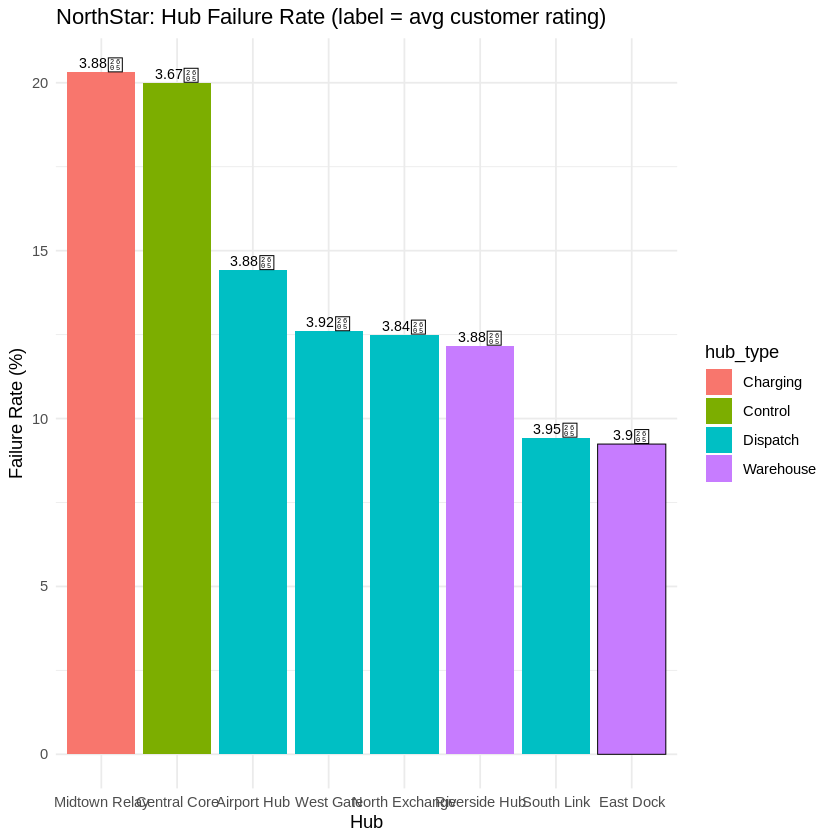

In [ ]:
# Visualise Q3
ggplot(q3, aes(x = reorder(hub_name, -failure_rate_pct),
               y = failure_rate_pct, fill = hub_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(avg_rating, "★")), vjust = -0.4, size = 3) +
  labs(title = "NorthStar: Hub Failure Rate (label = avg customer rating)",
       x = "Hub", y = "Failure Rate (%)") +
  theme_minimal()

This chart shows a significant variation in failure across Northstar's hub ranging from a low of 9.2% at East Dock to a high of 20.31% at Midtown Relay which is more than double and depicts a serious operational disparity.

the two worst performing hubs are Midtown Relay which is a charging hub and has a rating 20.31% and central core which is a control hub and has a rating of 20% which and both of them are located in the central zone. the fact that the highest failure rates are concentrated in the central zone is particularly concerning as this is likely the busiest and most commercially important area of North Star's network. notably Midtown Relay is a charging hub and not a dispatch hub Therefore it's failure rate may indicate that vehicle charging delays are causing knock on effects on delivery scheduling.

central core is a control hub which means failures originating from here could reflect to poor root allocation and planning decisions that cascade across the entire network rather than isolated delivery problems.

in contrast the best performing hubs are E stock with a percentage of 19.24% and S link 9.43%. Both of them are dispatch or warehouse type pubs that are operated in less congested zones.

despite these large differences in failure rates average customer ratings are remarkably similar across all hubs ranging only from 3.67 to 3.95. This shows that customers are not yet fully reflecting Hub level failures in their ratings Thus the true scale of operation problems may be understated in customer feedback alone and requires operational data analysis to uncover exactly the kind of integrated approach Northstar needs.

# QUERY 4: Driver Efficiency — Rating vs Experience vs Overrides
# Business question: Are manual route overrides linked to lower driver ratings or less experienced drivers?

In [ ]:
q4 <- sqldf("
  SELECT
    dr.employment_type,
    COUNT(d.delivery_id)                             AS total_deliveries,
    ROUND(AVG(dr.years_experience), 1)               AS avg_experience_yrs,
    ROUND(AVG(dr.driver_rating), 2)                  AS avg_driver_rating,
    ROUND(AVG(d.manual_route_override_count), 2)     AS avg_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2)   AS avg_customer_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.employment_type
  ORDER BY avg_overrides DESC
")

cat("\n--- Q4: Driver Efficiency by Employment Type ---\n")
print(q4)


--- Q4: Driver Efficiency by Employment Type ---
  employment_type total_deliveries avg_experience_yrs avg_driver_rating
1        FullTime              582                8.2              4.16
2        Contract              126                8.4              4.12
3        PartTime              242                8.3              4.20
  avg_overrides avg_customer_rating
1          1.02                3.87
2          0.93                3.83
3          0.86                3.88


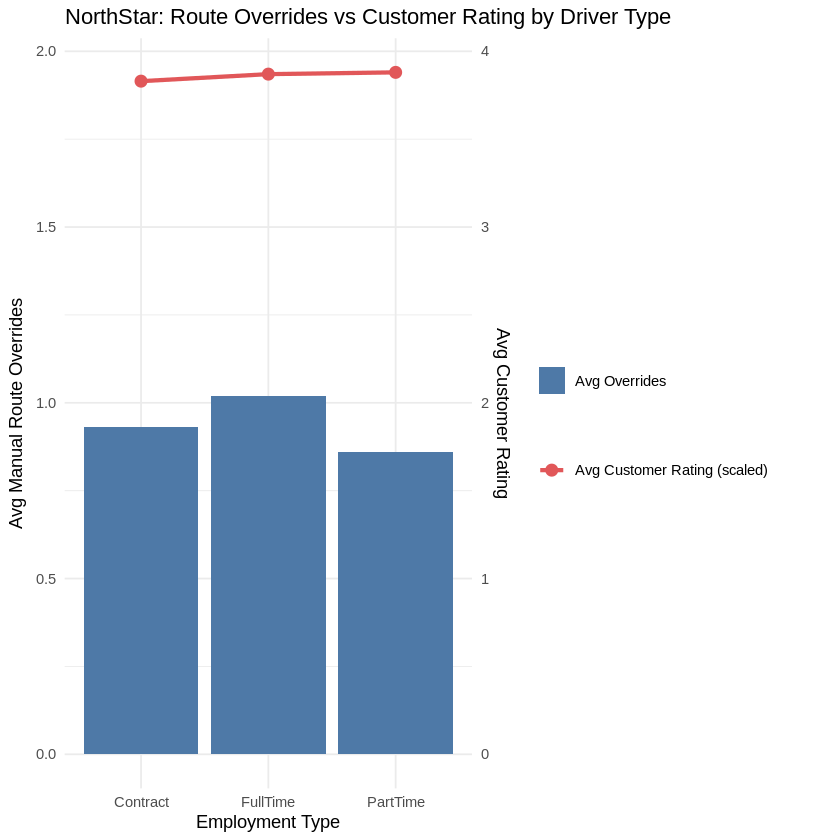

In [ ]:
# Visualise Q4
ggplot(q4, aes(x = employment_type)) +
  geom_bar(aes(y = avg_overrides, fill = "Avg Overrides"),
           stat = "identity", position = "dodge") +
  geom_line(aes(y = avg_customer_rating * 0.5, group = 1,
                colour = "Avg Customer Rating (scaled)"),
            linewidth = 1.2) +
  geom_point(aes(y = avg_customer_rating * 0.5,
                 colour = "Avg Customer Rating (scaled)"),
             size = 3) +
  scale_y_continuous(
    name = "Avg Manual Route Overrides",
    sec.axis = sec_axis(~ . / 0.5, name = "Avg Customer Rating")
  ) +
  scale_fill_manual(values = c("Avg Overrides" = "#4e79a7")) +
  scale_colour_manual(values = c("Avg Customer Rating (scaled)" = "#e15759")) +
  labs(title = "NorthStar: Route Overrides vs Customer Rating by Driver Type",
       x = "Employment Type", fill = "", colour = "") +
  theme_minimal()

The chart reveals a surprisingly narrow difference across all three employment types which is a meaningful finding for northstar.

In term of manual route overrides full time drivers record the highest average at 1.02 overrides per delivery which is slightly above the contract drivers which is 0.93 and part time drivers which is 0.86. This is counterintuitive as one might expect full time drivers with more experience to rely less on manual overrides. Instead their high override rate may suggest that they are more confident making rude judgements or alternatively that they are more likely to deviate from planned routes in order to avoid performance targets as the case study has suspected.


However the customer rating still a different story. Despite having the most overrides full time drivers achieve an average customer rating of 3.87 which is almost identical to both part time and contract drivers who have a rating of 3.88 and 3.83 respectively. The red line on the chart is nearly flat across all three groups which confirms that there is no meaningful difference in customer satisfaction by employment type.

Similarly years of experience are also identical across groups which is 8.2 to 8.4 years hence experience alone does not explain performance differences.

This suggests that the underperformance issues that are identified in N Star are not driven by employee type or experience level Instead the problems are more likely rooted in zone specific operational failures, route planning quality and hub management rather than the workforce composition itself.

# QUERY 5: High-Value Orders with Failed Deliveries
# Business question: Are high-priority or high-value orders being protected from failures, or are they equally at risk?

In [ ]:
q5 <- sqldf("
  SELECT
    o.priority_level,
    o.service_type,
    COUNT(d.delivery_id)                             AS total_orders,
    ROUND(AVG(o.order_value), 2)                     AS avg_order_value,
    SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                      AS failed_deliveries,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed'
               THEN 1 ELSE 0 END) * 100.0
      / COUNT(d.delivery_id), 2)                     AS failure_rate_pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.priority_level, o.service_type
  ORDER BY o.priority_level, failure_rate_pct DESC
")

cat("\n--- Q5: Failure Rates by Priority Level & Service Type ---\n")
print(q5)


--- Q5: Failure Rates by Priority Level & Service Type ---
   priority_level service_type total_orders avg_order_value failed_deliveries
1        Critical      Medical           10           71.76                 1
2        Critical     Business           10          102.06                 1
3        Critical    Passenger           19          100.59                 1
4        Critical       Retail           18           79.71                 0
5        Critical       Parcel           17           82.10                 0
6            High      Medical           21           87.82                 4
7            High     Business           35           92.77                 6
8            High       Retail           52           84.45                 8
9            High    Passenger           61          104.59                 9
10           High       Parcel           62           99.46                 5
11            Low    Passenger           77           95.60                15
12  

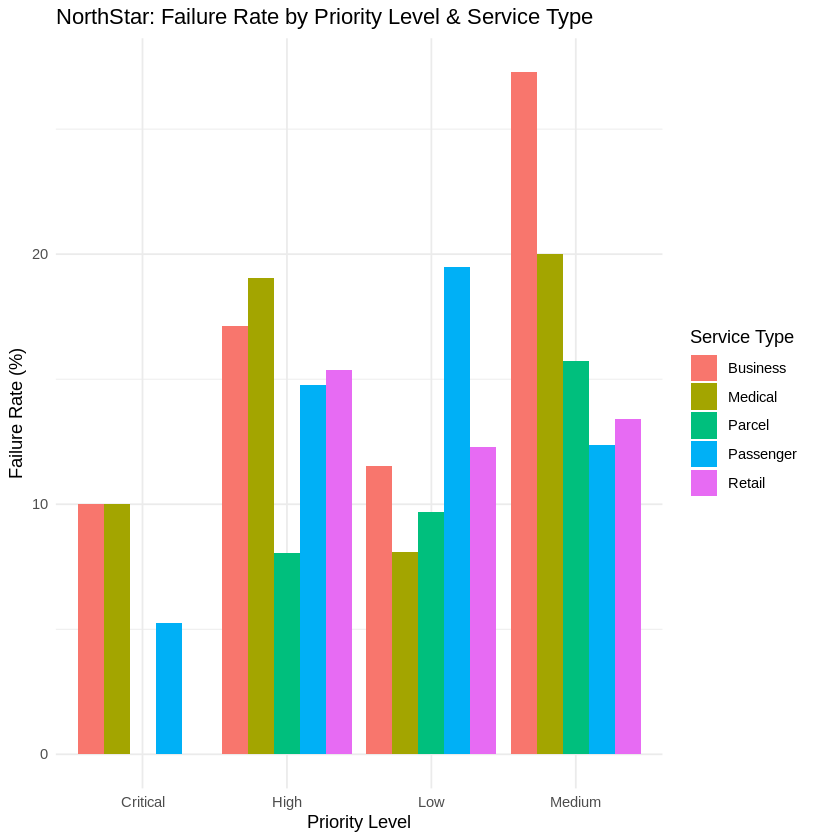

In [ ]:
# Visualise Q5
ggplot(q5, aes(x = priority_level, y = failure_rate_pct,
               fill = service_type)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "NorthStar: Failure Rate by Priority Level & Service Type",
       x = "Priority Level", y = "Failure Rate (%)", fill = "Service Type") +
  theme_minimal()

One of the most concerning findings from this analysis is that Medium Priority orders have the highest overall failure rates across nearly all service types with business services at medium priority recording the worst failure rate in the entire data set at 27.27%. This is paradoxical as one would expect critical and high priority orders to receive the most protection yet medium priority orders appear to be the most neglected.

critical priority orders perform best overall with retail and parcel recording 0% failure rates and passenger services at just 5.26%. This suggests N Star does apply some level of priority based resource allocation but only at the very top tier.

However high priority medical deliveries show failure rate of 19.05 percentage which is particularly alarming given the nature of this service. A failed medical delivery carries far greater consequences than a failed retail order yet the failure rate is among the highest in the high priority group.

The passenger service type shows a troubling pattern where failure rates increase steadily from critical which is 5.26% through Low which is 19.48% to Medium which is 12.38% suggesting passenger services lack consistent operational standards across priority tiers.

Overall these findings indicate that Northstar's Priority Management System is not functioning effectively below the critical tier and medium priority orders which make up the largest volume. These are being systematically underserved directly contributing to rising customer complaints and missed service Windows that are highlighted in the case study.

# QUERY 6 (Optimisation demo): Index-style filtering
# Using WHERE + subquery to efficiently retrieve only the worst-performing drivers (bottom 20% customer rating)

In [ ]:
q6 <- sqldf("
  SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(AVG(d.customer_rating_post_delivery), 2)  AS avg_cust_rating,
    COUNT(d.delivery_id)                            AS deliveries_done,
    SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                     AS failures
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id, dr.base_zone, dr.employment_type
  HAVING avg_cust_rating < (
    SELECT AVG(customer_rating_post_delivery) * 0.8
    FROM deliveries
  )
  ORDER BY avg_cust_rating ASC
  LIMIT 15
")

cat("\n--- Q6: Bottom Performing Drivers (below 80% of avg rating) ---\n")
print(q6)


--- Q6: Bottom Performing Drivers (below 80% of avg rating) ---
  driver_id base_zone employment_type avg_cust_rating deliveries_done failures
1      D063     north        PartTime            2.37               3        2
2      D111   Airport        FullTime            2.64               4        2
3      D076      East        FullTime            2.67               4        1
4      D141     North        PartTime            2.93               9        2
5      D165     North        PartTime            2.98               6        2


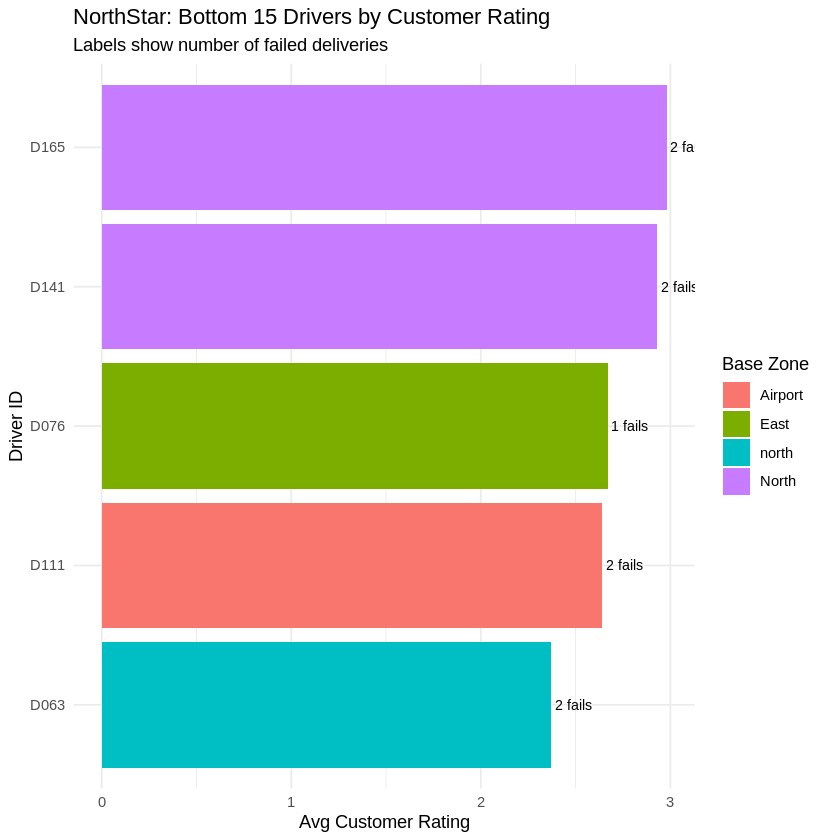

In [ ]:
# Visualise Q6
ggplot(q6, aes(x = reorder(driver_id, avg_cust_rating),
               y = avg_cust_rating, fill = base_zone)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(failures, " fails")),
            hjust = -0.1, size = 3) +
  coord_flip() +
  labs(title = "NorthStar: Bottom 15 Drivers by Customer Rating",
       subtitle = "Labels show number of failed deliveries",
       x = "Driver ID",
       y = "Avg Customer Rating",
       fill = "Base Zone") +
  theme_minimal()

The query identifies 5 drivers whose average customer rating fell below 80% of the network average, with ratings ranging from 2.37 to 2.98 out of 5.

The lowest rated driver is D063 (North Zone, Part Time) with an average rating of just 2.37, with a recording of 2 failures out of only 3 deliveries resulying in a failure rate of 67%, which is alarmingly high. Similarly, D111 (Airport, Full-Time) both recorded 2 and 1 failures respectively across 4 deliveries each.

A notable pattern emerges around the employment type, such that 3 out of 5 underperfoming drivers are part-timr (D063,D141,D165) suggesting rthat part-timr drivers may have less consistency or familiarity with routes. Additionally, 2 out of 5 drivers are based in the North Zone (D141,D165) whixxh aligns with the findings from Q2 where the North Zone showed a higher failure rate.

These results suggest NORTHSTAR should investigate whether part time staffing levels and zone specific operational issues are contributing to chronic underperformance in certain areas. rather than treating poor ratings as isolated individual problems.




# NorthStar Urban Mobility & Logistics
# Section 2: R Analytics
# Tools: ggplot2, dplyr, statistical methods

In [ ]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("lubridate")
install.packages("corrplot")

library(dplyr)
library(ggplot2)
library(lubridate)
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


corrplot 0.95 loaded



# ANALYSIS 1: Descriptive Statistics — Delivery Performance
# Business question: What does the overall distribution of delivery outcomes look like across the NorthStar network?


--- A1: Descriptive Statistics for Key Delivery Metrics ---
  avg_rating median_rating sd_rating avg_distance_km avg_fuel_cost
1       3.86          4.04      0.89           13.91         12.84
  total_deliveries
1              950


Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_bin()`).”


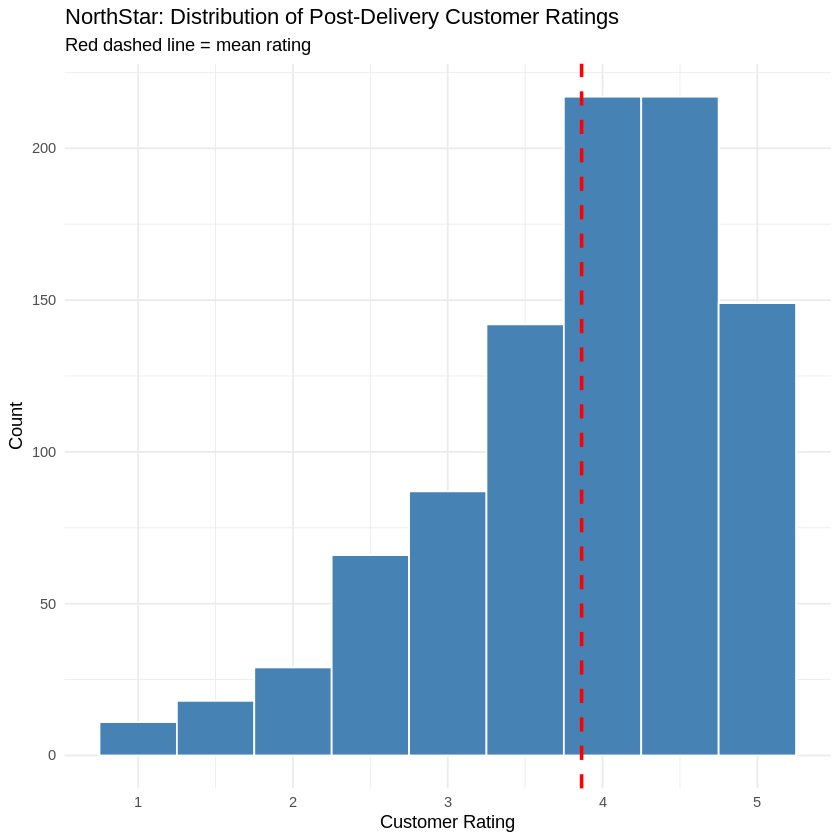

In [ ]:
cat("\n--- A1: Descriptive Statistics for Key Delivery Metrics ---\n")
delivery_stats <- deliveries %>%
  summarise(
    avg_rating       = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    median_rating    = round(median(customer_rating_post_delivery, na.rm = TRUE), 2),
    sd_rating        = round(sd(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_distance_km  = round(mean(route_distance_km, na.rm = TRUE), 2),
    avg_fuel_cost    = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    total_deliveries = n()
  )
print(delivery_stats)

# Distribution of customer ratings
ggplot(deliveries, aes(x = customer_rating_post_delivery)) +
  geom_histogram(binwidth = 0.5, fill = "steelblue", colour = "white") +
  geom_vline(aes(xintercept = mean(customer_rating_post_delivery, na.rm = TRUE)),
             colour = "red", linetype = "dashed", linewidth = 1) +
  labs(title = "NorthStar: Distribution of Post-Delivery Customer Ratings",
       subtitle = "Red dashed line = mean rating",
       x = "Customer Rating", y = "Count") +
  theme_minimal()

The histogram shows that the distribution is left-skewed, as most of NorthStar's customers give positive ratings on their deliveries but there is a significant tail of negative ratings, which drags the mean down from the maximum.

This is a difference between the mean rating of 3.86 and the median rating of 4.04, and that is significant as the median rating exceeds the mean, indicating a left skew, with a smaller number of ratings in the low range (1.0–2.5) pulling the average lower. Visually this is confirmed by the red dashed mean line just below the 4.0 mark.
The number of deliveries for each rating band is maximized in the 4.0–4.5 band, with about 220 deliveries in each rating band.

Around 150 deliveries have a rating of 5.0, representing a good level of satisfaction. But the steady climb of the ratings from 1.0 to 3.5 (several hundred delivery ratings) is significant because it includes a large number of customers who are not satisfied or just moderately satisfied.

A standard deviation of 0.89 means there is moderate variation from the average result, and that customers' experiences with NorthStar are not uniformly acceptable, but rather there are some who continually receive very good service, and others who continually receive very poor service.

The operational cost per delivery is relevant because our average route distance is 13.91km and our average fuel cost per delivery is £12.84, meaning that every failed or delayed delivery represents a loss of money with no corresponding revenue.

# ANALYSIS 2: Correlation Analysis — Driver Attributes
# Business question: Which driver attributes (experience, training score) are most strongly linked to performance?


--- A2: Correlation Between Driver Attributes & Performance ---
                 years_experience training_score driver_rating avg_cust_rating
years_experience             1.00           0.11          0.10           -0.19
training_score               0.11           1.00         -0.07            0.01
driver_rating                0.10          -0.07          1.00            0.24
avg_cust_rating             -0.19           0.01          0.24            1.00
avg_overrides                0.01          -0.05          0.00           -0.16
failure_rate                 0.21           0.09         -0.22           -0.47
                 avg_overrides failure_rate
years_experience          0.01         0.21
training_score           -0.05         0.09
driver_rating             0.00        -0.22
avg_cust_rating          -0.16        -0.47
avg_overrides             1.00         0.08
failure_rate              0.08         1.00


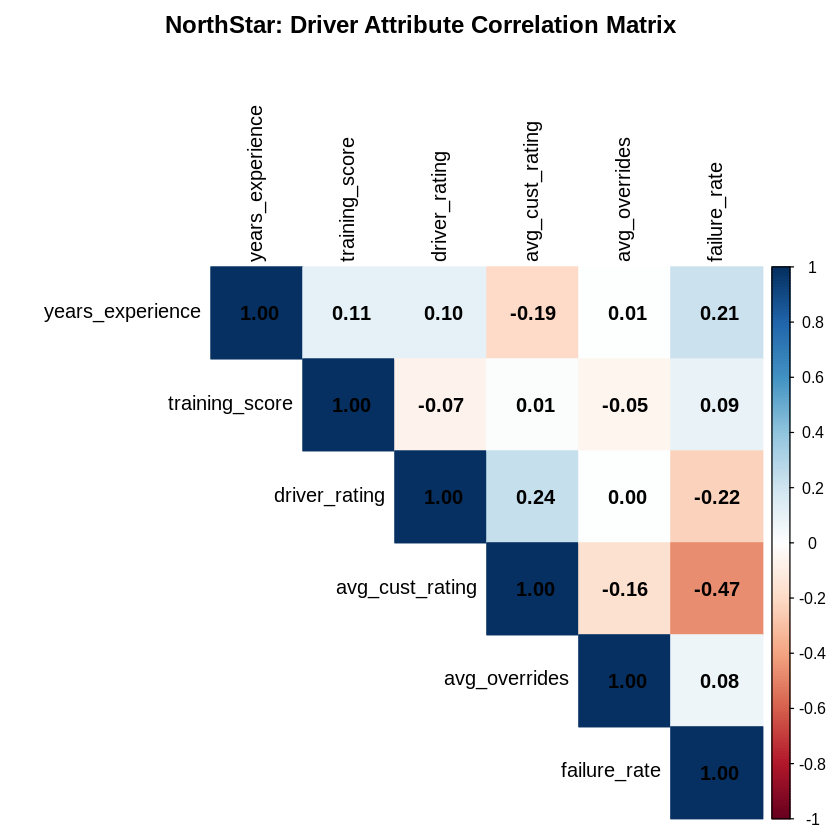

In [ ]:
cat("\n--- A2: Correlation Between Driver Attributes & Performance ---\n")

# Merge driver info with delivery outcomes
driver_perf <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    avg_cust_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_overrides   = mean(manual_route_override_count, na.rm = TRUE),
    failure_rate    = mean(delivery_status == "Failed", na.rm = TRUE)
  ) %>%
  left_join(drivers, by = "driver_id")

# Correlation matrix
cor_data <- driver_perf %>%
  select(years_experience, training_score, driver_rating,
         avg_cust_rating, avg_overrides, failure_rate) %>%
  na.omit()

cor_matrix <- cor(cor_data)
print(round(cor_matrix, 2))

corrplot(cor_matrix,
         method = "color",
         type   = "upper",
         addCoef.col = "black",
         tl.col = "black",
         title  = "NorthStar: Driver Attribute Correlation Matrix",
         mar    = c(0, 0, 2, 0))

This correlation matrix is one of the most analytically rich outputs in the entire section and shows a number of important correlations between driver attributes and delivery performance.

The largest relationship in the whole matrix is between avg_cust_rating and failure_rate at -0.47, or moderate negative, in orange/red. For example, drivers with positive customer ratings generally have much lower failure rates, which is an indication that customer satisfaction and operational reliability are indeed correlated at the driver level. This is the most practical discovery for the management of NorthStar.

There is a positive correlation between driver_rating and avg_cust_rating of 0.24, indicating a certain amount of validity in NorthStar's internal driver rating system: Drivers who rate better internally tend to get better customer feedback, but not enough to base everything on the internal rating system.

driver_rating and failure_rate are correlated at -0.22, which implies that better-rated drivers do indeed fail less, but again the correlation is modest and suggest other factors beyond individual driver quality is responsible for failures, consistent with the zone and hub findings throughout this analysis.

Interestingly, years_experience is weakly positively correlated with failure_rate (correlation of 0.21) suggesting that very slightly, those with more experience tend to have higher failure rates. This surprising result could indicate that more experienced drivers are being assigned more complex or challenging routes, or that experience doesn't make any impact to offset NorthStar's operational issues.

Most importantly, training_score has near-zero correlations across all performance measures (0.01 with avg_cust_rating, 0.09 with failure_rate), which is concerning for the board, especially given the investment in driver training, as it indicates that the current training programme is not having a meaningful impact on actual delivery outcomes.

# ANALYSIS 3: Trend Analysis — Delivery Failures Over Time
# Business question: Are delivery failures increasing over time, or are there seasonal patterns to address?


--- A3: Monthly Delivery Failure Trend ---
# A tibble: 72 × 3
   month_year          delivery_status count
   <dttm>              <chr>           <int>
 1 2024-01-01 00:00:00 Delayed            13
 2 2024-01-01 00:00:00 Failed              1
 3 2024-01-01 00:00:00 OnTime             31
 4 2024-02-01 00:00:00 Delayed             6
 5 2024-02-01 00:00:00 Failed              7
 6 2024-02-01 00:00:00 OnTime             33
 7 2024-03-01 00:00:00 Delayed             9
 8 2024-03-01 00:00:00 Failed              5
 9 2024-03-01 00:00:00 OnTime             38
10 2024-04-01 00:00:00 Delayed             6
# ℹ 62 more rows


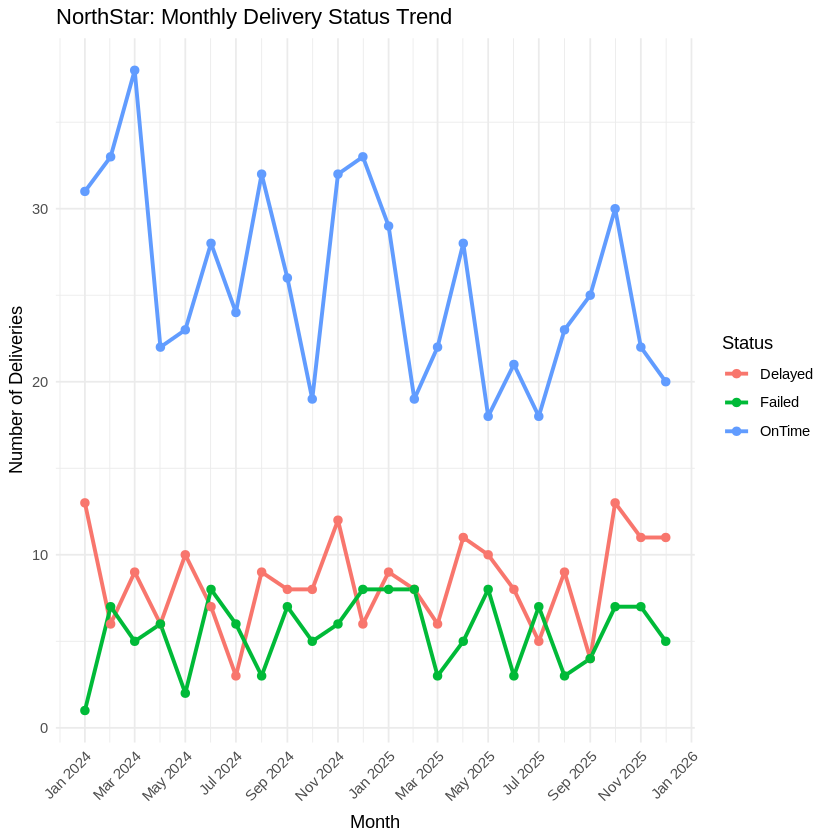

In [ ]:
cat("\n--- A3: Monthly Delivery Failure Trend ---\n")

deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time)
deliveries$month_year    <- floor_date(deliveries$dispatch_time, "month")

monthly_trend <- deliveries %>%
  group_by(month_year, delivery_status) %>%
  summarise(count = n(), .groups = "drop")

print(monthly_trend)

ggplot(monthly_trend, aes(x = month_year, y = count,
                           colour = delivery_status, group = delivery_status)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2) +
  labs(title = "NorthStar: Monthly Delivery Status Trend",
       x = "Month", y = "Number of Deliveries", colour = "Status") +
  theme_minimal() +
  scale_x_datetime(date_labels = "%b %Y", date_breaks = "2 months") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The trend chart covers two years of Northstar's delivery activities, and shows some significant trends in all three delivery statuses.

The OnTime line (blue) is the most erratic over the entire timeframe, with peaks as high as 38 deliveries in March 2024, and lows of approximately 18 deliveries in July 2025. Interestingly, on-time deliveries don't seem to have gotten better over the course of the two years, as the line fluctuates without rising, indicating that NorthStar has not improved on delivering on time over time, despite the increase in demand.

Delayed deliveries (red) continue to be abnormally high for much of the time, never falling below 5 deliveries per month, but rising significantly in January 2024 (13), November 2024 (12) and November 2025 (13). In particular, the frequent peaks in November-January are worrying as they indicate a seasonal demand pressure, probably caused by a higher level of commercial activity during the holiday season, and NorthStar seems to be consistently under-prepared to deal with this year in and year out.

Failed deliveries (green) are fairly low and consistent throughout, averaging around 3-8 per month. The presence of non-near-zero failures in each month, however, shows that the failure rate is not reaching near zero; there is an underlying chronic failure rate in the network's operations.

The biggest lesson to be learned is the lack of any positive trend across the three lines over the last two years; NorthStar isn't improving over time. As a result of gathering greater data than ever, as stated in the case study, performance has not improved, thus the need for an integrated data-driven approach that this analysis can provide.

# ANALYSIS 4: Boxplot — Customer Ratings by Zone
# Business question: Do customers in certain zones consistently receive worse service than others?


--- A4: Customer Rating Distribution by Pickup Zone ---


Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


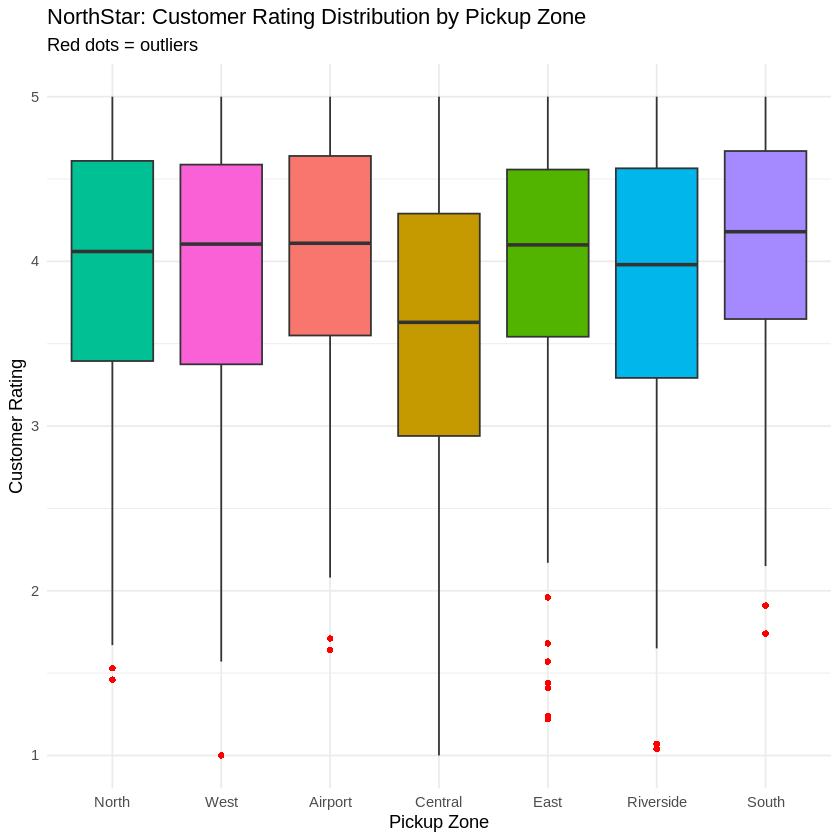

In [ ]:
cat("\n--- A4: Customer Rating Distribution by Pickup Zone ---\n")

zone_ratings <- deliveries %>%
  left_join(orders, by = "order_id")

ggplot(zone_ratings, aes(x = reorder(pickup_zone, customer_rating_post_delivery,
                                      FUN = median),
                          y = customer_rating_post_delivery,
                          fill = pickup_zone)) +
  geom_boxplot(outlier.colour = "red", outlier.shape = 16) +
  labs(title = "NorthStar: Customer Rating Distribution by Pickup Zone",
       subtitle = "Red dots = outliers",
       x = "Pickup Zone", y = "Customer Rating") +
  theme_minimal() +
  theme(legend.position = "none")

The boxplot shows that although the surface ratings for most zones are similar, the ratings for customers in Central are definitely out of the range for the other zones, and there are a lot of ratings that are not in line with the rest.

The median rating of Central is around 3.5, distinctly lower than the rest of the zones which are around 4.0-4.2 on average. More strikingly, the interquartile range (the box) for Central is a wide range, located below and covering from about 2.9 to 4.3, suggesting high variability in service levels, as in some instances the service is good and in many instances it is poor. The wide spread implies that things are not uniformly bad at Central, but rather that there are a variety of factors and challenges that can arise in the future.

South performs best with the highest median rating of approximately 4.2 and a relatively compact box, suggesting more consistent service delivery which aligns with its lowest failure rate of 25.9% found in Q2.

The distributions in all other directions (North, West, Airport, East, and Riverside) are similar with a median of approximately 4.0 and comparable box sizes indicating broadly similar service levels across these zones.

The red outlier dots show that poor ratings (less than 2.0) are found throughout the network, not just in Central. This means that a structural failure of performance exists in Central, but failures at a few points throughout the network have created a problem that needs to be systematically solved in NorthStar.

Overall this chart validates the previous discovery that Central needs priority intervention, but also shows that there are no zones without service quality issues.

# ANALYSIS 5: Statistical Test — Do Full-Time Drivers
# Perform Better Than Part-Time Drivers?
# Business question: Is there a statistically significant difference in delivery ratings between employment types?


--- A5: T-Test — FullTime vs PartTime Driver Ratings ---

	Welch Two Sample t-test

data:  fulltime and parttime
t = -0.20611, df = 431.05, p-value = 0.8368
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.1528035  0.1237980
sample estimates:
mean of x mean of y 
 3.865622  3.880124 


Interpretation:
  p >=0.05 — No statistically significant difference in ratings.


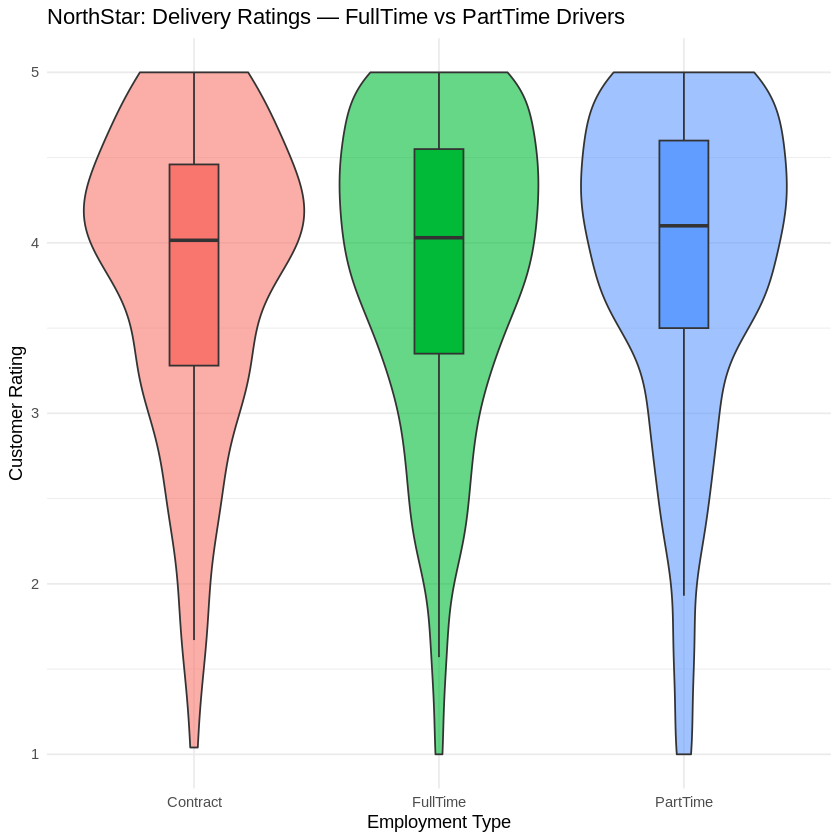

In [ ]:
cat("\n--- A5: T-Test — FullTime vs PartTime Driver Ratings ---\n")

driver_ratings <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  select(customer_rating_post_delivery, employment_type) %>%
  na.omit()

fulltime <- driver_ratings %>%
  filter(employment_type == "FullTime") %>%
  pull(customer_rating_post_delivery)

parttime <- driver_ratings %>%
  filter(employment_type == "PartTime") %>%
  pull(customer_rating_post_delivery)

t_result <- t.test(fulltime, parttime)
print(t_result)

cat("\nInterpretation:\n")
if (t_result$p.value < 0.05) {
  cat("  p <0.05 — There IS a statistically significant difference in ratings.\n")
} else {
  cat("  p >=0.05 — No statistically significant difference in ratings.\n")
}

# Visualise A5
ggplot(driver_ratings, aes(x = employment_type,
                            y = customer_rating_post_delivery,
                            fill = employment_type)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.2, outlier.shape = NA) +
  labs(title = "NorthStar: Delivery Ratings — FullTime vs PartTime Drivers",
       x = "Employment Type", y = "Customer Rating") +
  theme_minimal() +
  theme(legend.position = "none")

The P-value of the Welch two sample t-test is 0.8368, well above the 0.05 significance level. Therefore, we do not reject the null hypothesis, meaning that the means of the two populations are not significantly different at NorthStar.

The mean ratings are virtually the same (Full-Time drivers have an average of 3.87, Part-Time drivers have an average rating of 3.88, with a difference of 0.015, which is statistically and practically insignificant). The 95% confidence interval (-0.153 to 0.124) crosses the value of zero again, indicating that there is no meaningful difference.

This is also reflected by the violin plot. The distributions of all three employment types (Contract, Full-Time, and Part-Time) are very similar. All ratings groups have a median rating between about 4.0 and 4.5, with the bulk of ratings falling between 3.5 and 4.5. Occasional very poor ratings are also evident across all employment types in each violin, with a thin tail stretching down to 1.0.

This is a statistically sound result and a direct challenge to a widespread belief in workforce management; namely that more dedicated drivers, such as full-time employees, provide better customer service than part-time or contract drivers. As at NorthStar, there is no correlation between employment and service quality.

Together with the Q4 results, this is a clear indication that NorthStar needs to focus its efforts on addressing operational and structural issues (better planning of routes, management of hubs, and allocation of resources at the zone level) that the data has repeatedly identified as the actual issues.

# ANALYSIS 6: App Engagement vs Customer Loyalty
# Business question: Does higher app engagement lead to better loyalty scores among NorthStar customers?


--- A6: Correlation — App Engagement vs Loyalty Score ---
Pearson correlation (app engagement vs loyalty): 0.036 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


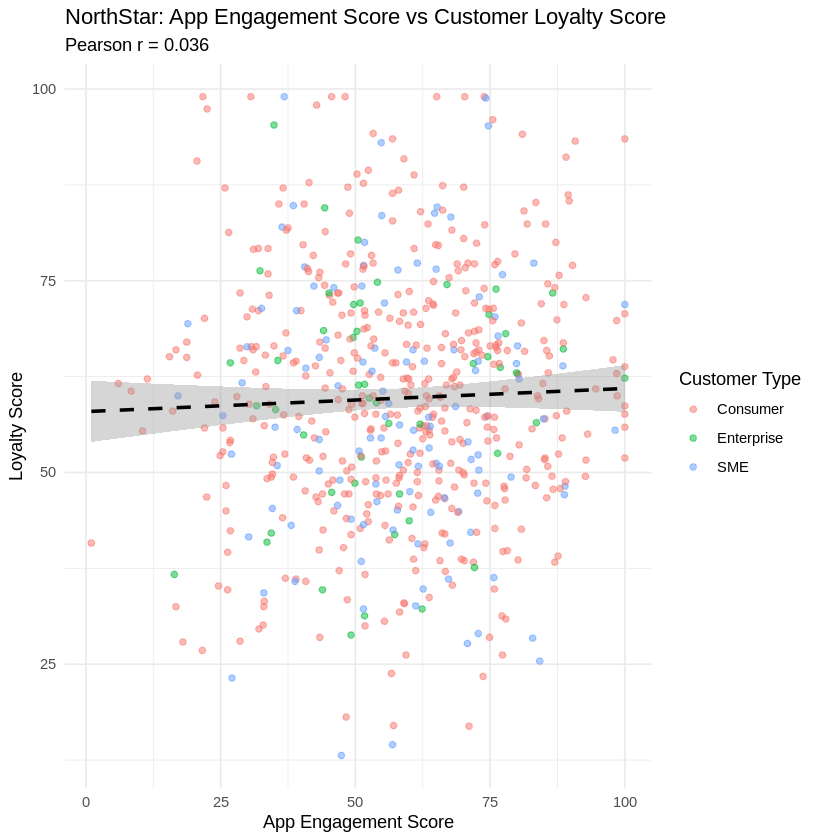

In [ ]:
cat("\n--- A6: Correlation — App Engagement vs Loyalty Score ---\n")

cor_val <- cor(customers$app_engagement_score,
               customers$loyalty_score, use = "complete.obs")
cat("Pearson correlation (app engagement vs loyalty):", round(cor_val, 3), "\n")

ggplot(customers, aes(x = app_engagement_score, y = loyalty_score,
                       colour = customer_type)) +
  geom_point(alpha = 0.5, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, colour = "black", linetype = "dashed") +
  labs(title = "NorthStar: App Engagement Score vs Customer Loyalty Score",
       subtitle = paste0("Pearson r = ", round(cor_val, 3)),
       x = "App Engagement Score", y = "Loyalty Score",
       colour = "Customer Type") +
  theme_minimal()


The scatter plot and Pearson correlation value of r = 0.036 reveals an almost completely flat relationship between app engagement and customer loyalty at NorthStar. A Pearson r close to 0 signifies near nonexistent linear correlation between customer engagement with the app and customer loyalty towards the service.

The dashed regression is fairly flat, and the data is very broad in all combinations of engagement and loyalty scores — customers with very low levels of app engagement (close to 0) can have very high levels of loyalty (near 100), while similarly very high levels of app engagement can be combined with very high scores of loyalty (between 20 and 100).

For NorthStar's technology director, it's an important discovery, since he has directed investment in the mobile platform as an integral component of the customer experience strategy. The data indicates that the retention or loyalty of customers is not being achieved from app engagement, only. Customers tend to stay loyal or not loyal, and not based on how often they use the app.

The engagement-loyalty relationship is the same for all three customer segments, Consumer, Enterprise and SME, and there is no significant difference between the relationship of any of the groups.

The business takeaway is easy: NorthStar should keep in mind that more usage of the app does not lead to better loyalty scores. Rather, it's probably about the actual service quality, that is, on-time delivery, complaints addressed, and reliability, all three of which are currently lagging, according to the data.